In [14]:
!pip install opencv-python scikit-image scikit-learn

In [15]:
import numpy as np
import cv2
import zipfile
import os

from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from google.colab import files

In [16]:
uploaded = files.upload()
zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/flowers")

Saving Aryan flowers.zip to Aryan flowers.zip


In [17]:
base = "/content/flowers"

# Fix nested folder issue
if len(os.listdir(base)) == 1:
    base = os.path.join(base, os.listdir(base)[0])

dataset_path = base
classes = sorted(os.listdir(dataset_path))

print("Classes:", classes)

Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [18]:
def augment_image(image):
    aug = []

    # original + flips
    aug.append(image)
    aug.append(cv2.flip(image, 1))
    aug.append(cv2.flip(image, 0))

    # rotations
    for angle in [15, -15, 30, -30, 45, -45, 60]:
        h, w = image.shape[:2]
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
        aug.append(cv2.warpAffine(image, M, (w, h)))

    # zoom
    for scale in [0.8, 1.2, 1.3]:
        resized = cv2.resize(image, None, fx=scale, fy=scale)
        resized = cv2.resize(resized, (128,128))
        aug.append(resized)

    # brightness
    aug.append(cv2.convertScaleAbs(image, alpha=1.2, beta=30))
    aug.append(cv2.convertScaleAbs(image, alpha=0.8, beta=-30))

    # blur
    aug.append(cv2.GaussianBlur(image, (5,5), 0))

    return aug

In [19]:
data = []
labels = []

target = 300  # samples per class

for label, cls in enumerate(classes):
    path = os.path.join(dataset_path, cls)
    count = 0

    for img in os.listdir(path):
        if count >= target:
            break

        img_path = os.path.join(path, img)
        image = cv2.imread(img_path)

        if image is None:
            continue

        image = cv2.resize(image, (128,128))
        augmented = augment_image(image)

        for aug_img in augmented:
            if count >= target:
                break

            gray = cv2.cvtColor(aug_img, cv2.COLOR_BGR2GRAY)

            features = hog(gray,
                           pixels_per_cell=(8,8),
                           cells_per_block=(2,2))

            data.append(features)
            labels.append(label)

            count += 1

    print(f"{cls} → {count} samples generated")

daisy → 300 samples generated
dandelion → 300 samples generated
rose → 300 samples generated
sunflower → 300 samples generated
tulip → 300 samples generated


In [20]:
X = np.array(data)
y = np.array(labels)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data ready:", X_train.shape)

Data ready: (1200, 8100)


In [21]:
model = SVC(kernel='rbf', C=20, gamma='scale')
model.fit(X_train, y_train)

print("Model Trained!")

Model Trained!


In [22]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.73

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.73      0.73        56
           1       0.65      0.71      0.68        65
           2       0.74      0.82      0.78        49
           3       0.88      0.65      0.75        66
           4       0.71      0.77      0.74        64

    accuracy                           0.73       300
   macro avg       0.74      0.73      0.73       300
weighted avg       0.74      0.73      0.73       300



Saving 00f6e89a2f949f8165d5222955a5a37d.jpg to 00f6e89a2f949f8165d5222955a5a37d.jpg
Uploaded Image:


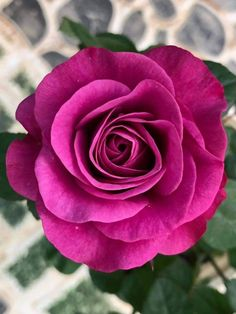


🔝 Top 3 Predictions:
rose : 70.00%
tulip : 20.15%
daisy : 6.94%

Final Prediction: rose


In [23]:
from google.colab.patches import cv2_imshow

test = files.upload()

for file_name, file in test.items():
    file_bytes = np.frombuffer(file, np.uint8)
    image = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    # Show image
    print("Uploaded Image:")
    cv2_imshow(image)

    # Preprocess
    image_resized = cv2.resize(image, (128,128))
    gray = cv2.cvtColor(image_resized, cv2.COLOR_BGR2GRAY)

    # HOG features
    features = hog(gray,
                   pixels_per_cell=(8,8),
                   cells_per_block=(2,2))

    features = scaler.transform([features])

    # Get probabilities (IMPORTANT CHANGE)
    probs = model.decision_function(features)[0]

    # Convert to probability-like scores
    probs = np.exp(probs) / np.sum(np.exp(probs))

    # Top 3 predictions
    top3 = np.argsort(probs)[-3:][::-1]

    print("\n🔝 Top 3 Predictions:")
    for i in top3:
        print(f"{classes[i]} : {probs[i]*100:.2f}%")

    # Final prediction
    pred = top3[0]
    print("\nFinal Prediction:", classes[pred])